In [ ]:
import torch 

data = torch.load('./data/AudioSet/AudioSet.pt')

In [39]:
data['mapping']

{0: 'Wild animals',
 1: 'Domestic animals, pets',
 2: 'Bell',
 3: 'Alarm',
 4: 'Wind',
 5: 'Water',
 6: 'Wild animals+Domestic animals, pets',
 7: 'Bell+Alarm',
 8: 'Wind+Water',
 9: 'PinkNoise'}

In [3]:
index_1 = 4
index_2 = 5
mel_indices_1 = data['audio_index']['train'][index_1]
mel_indices_2 = data['audio_index']['train'][index_2]
mel_1 = [data['ds_logmel']['train']['log_mel'][i] for i in mel_indices_1]
mel_2 = [data['ds_logmel']['train']['log_mel'][i] for i in mel_indices_2]
mel_1 = torch.tensor(mel_1)
mel_2 = torch.tensor(mel_2)
# mel_1.mean(dim=0).size()
# import seaborn as sns 
# torch.abs(mel_1.mean(dim=0)-mel_2.mean(dim=0)).mean()

tensor(4.6989)

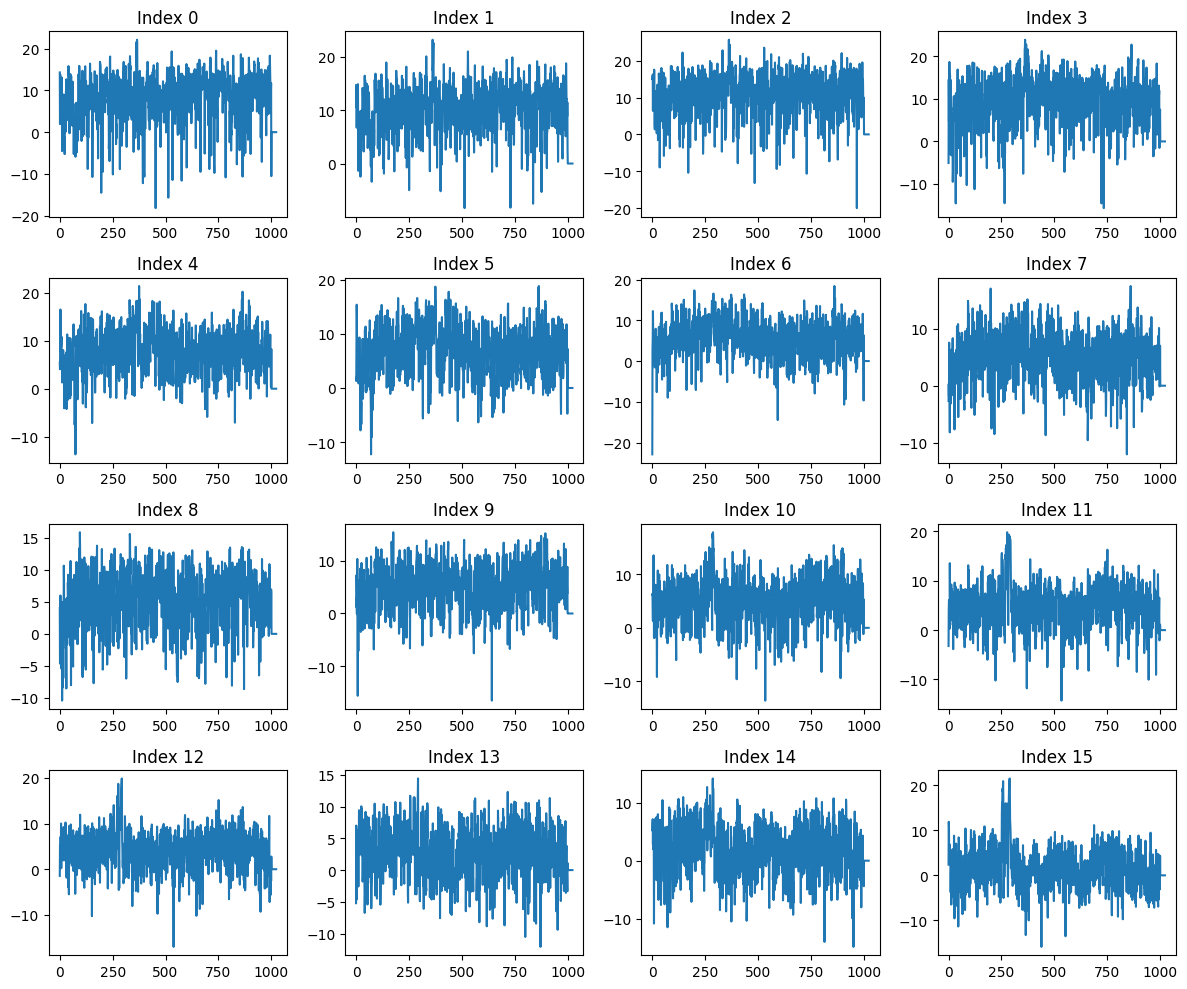

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i in range(16):
    row = i // 4
    col = i % 4
    time_wave = mel_1[1, i, :]
    axes[row, col].plot(time_wave)
    axes[row, col].set_title(f'Index {i}')

plt.tight_layout()
plt.show()


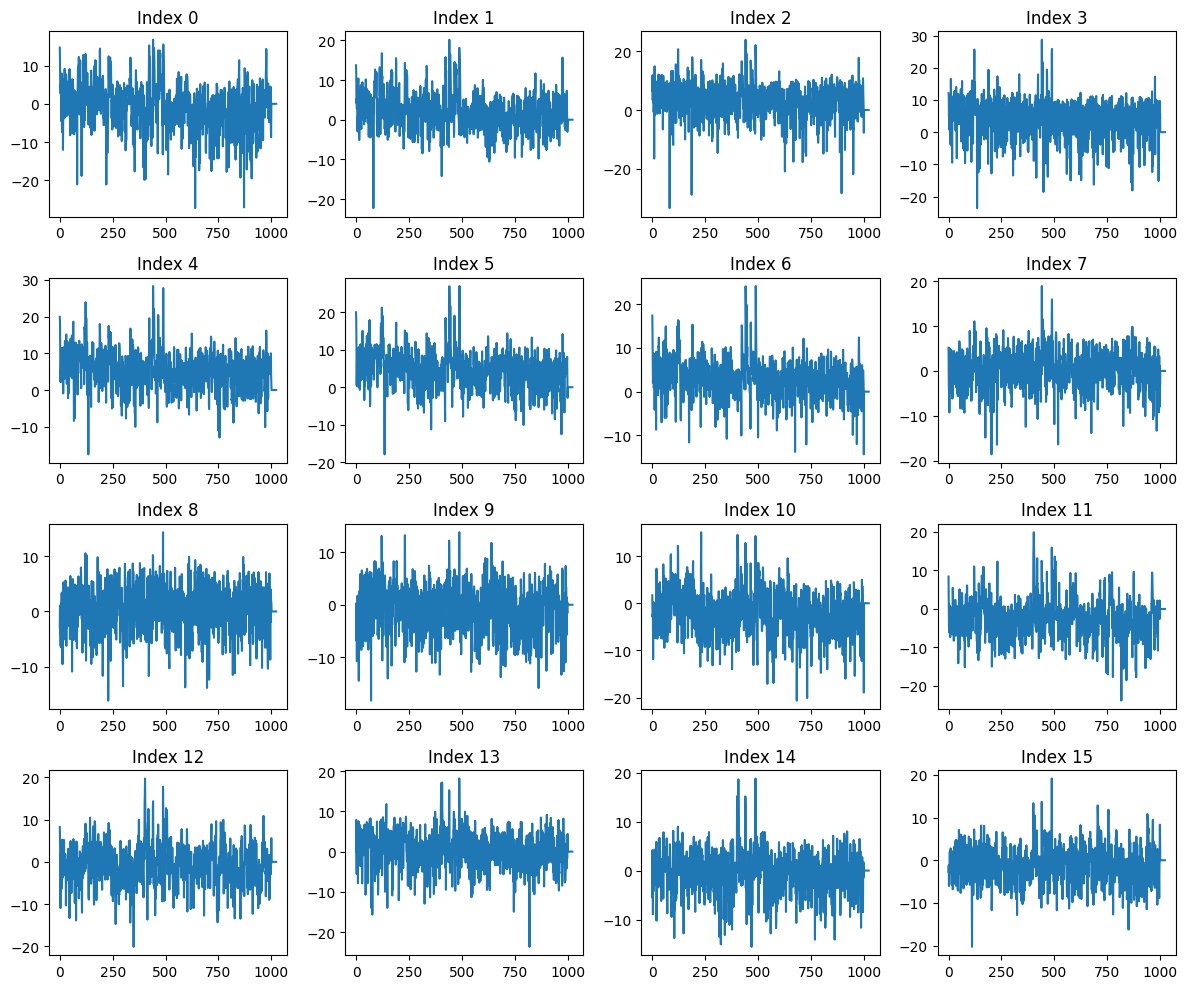

In [25]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i in range(16):
    row = i // 4
    col = i % 4
    time_wave = mel_2[2, i, :]
    axes[row, col].plot(time_wave)
    axes[row, col].set_title(f'Index {i}')

plt.tight_layout()
plt.show()


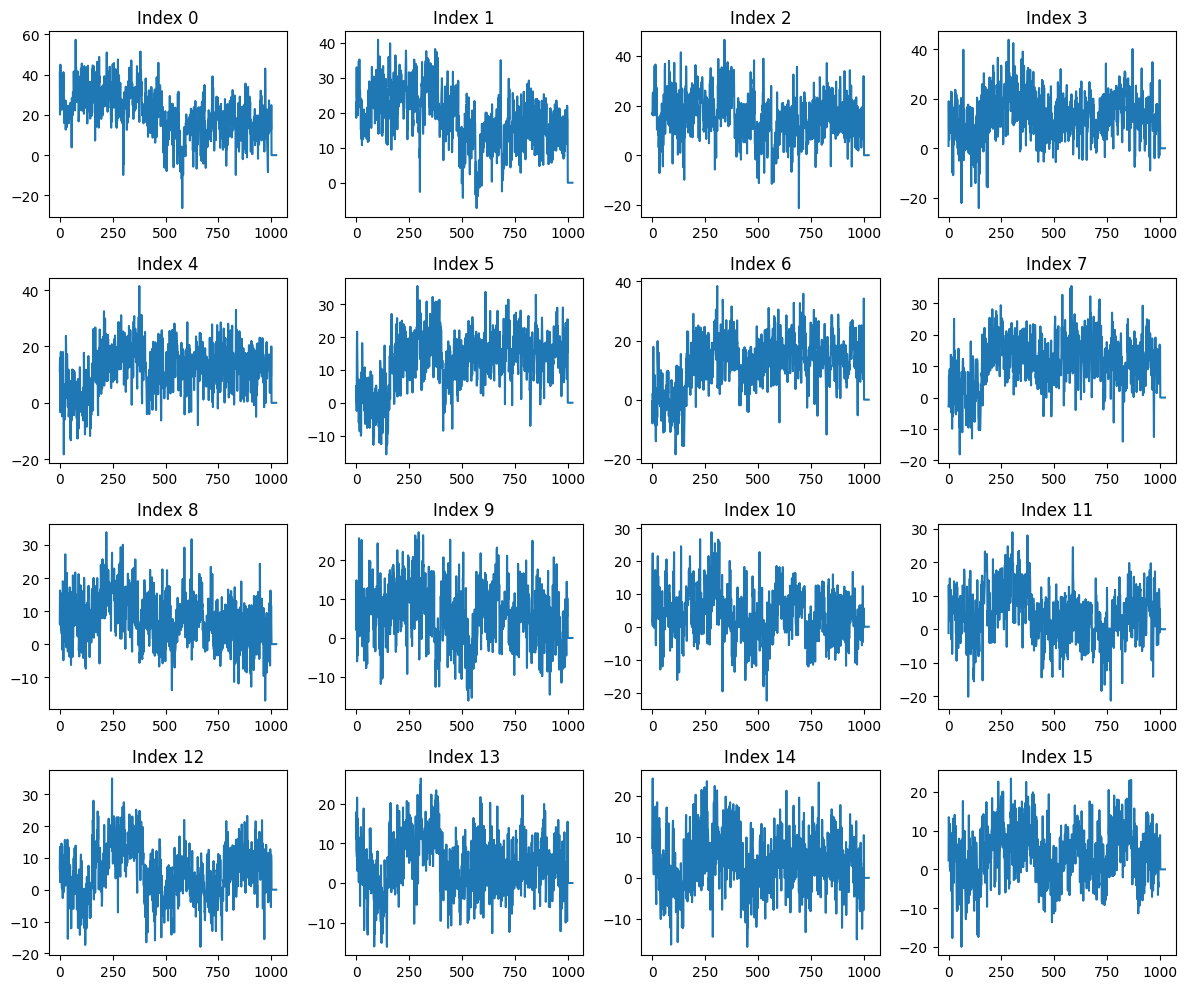

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 4, figsize=(12, 10))

for i in range(16):
    row = i // 4
    col = i % 4
    time_wave = mel_1[0, i, :]-mel_2[0,i,:]
    axes[row, col].plot(time_wave)
    axes[row, col].set_title(f'Index {i}')

plt.tight_layout()
plt.show()


In [31]:
index_3 = 9
# mel_indices_1 = data['audio_index']['train'][index_1]
mel_indices_3 = data['audio_index']['train'][index_3]
# mel_1 = [data['ds_logmel']['train']['log_mel'][i] for i in mel_indices_1]
mel_3 = [data['ds_logmel']['train']['log_mel'][i] for i in mel_indices_3]
# mel_1 = torch.tensor(mel_1)
mel_3 = torch.tensor(mel_3)
# mel_1.mean(dim=0).size()
# import seaborn as sns 
torch.abs(mel_1.mean(dim=0)-mel_1[0]).sum(dim=1).size()

torch.Size([64])

In [45]:
index_4 = 2
# mel_indices_1 = data['audio_index']['train'][index_1]
mel_indices_4 = data['audio_index']['train'][index_4]
# mel_1 = [data['ds_logmel']['train']['log_mel'][i] for i in mel_indices_1]
mel_4 = [data['ds_logmel']['train']['log_mel'][i] for i in mel_indices_4]
# mel_1 = torch.tensor(mel_1)
mel_4 = torch.tensor(mel_4)
# mel_1.mean(dim=0).size()
# import seaborn as sns 
# torch.abs(mel_1.mean(dim=0)-mel_1[0]).sum(dim=1).size()

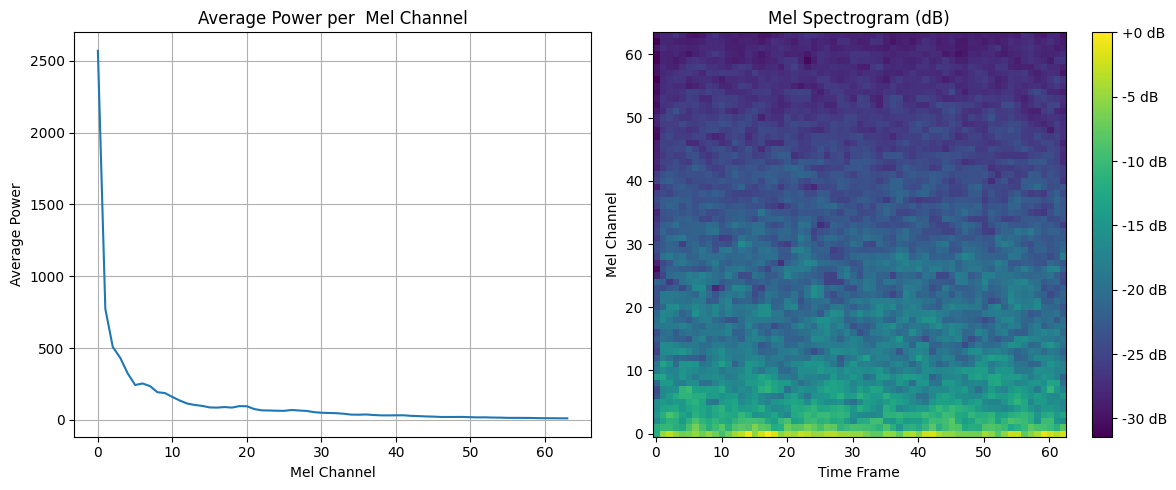

Shape of mel_spec: (64, 63)
Average energy per channel: [2570.08225563  772.52032534  507.31857199  431.84181516  323.4518235 ]


In [1]:
import librosa
import numpy as np
import colorednoise as cn
import matplotlib.pyplot as plt

# 生成粉噪声
sample_rate = 16000
duration = 2  # 秒
pink = cn.powerlaw_psd_gaussian(1, sample_rate * duration)

# 计算梅尔频谱
mel_spec = librosa.feature.melspectrogram(
    y=pink, 
    sr=sample_rate, 
    n_mels=64,
    n_fft=2048,
    hop_length=512
)

# 转换为dB
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

# 计算每个mel通道的平均能量(类似你的代码)
avg_energy_per_mel = np.mean(mel_spec, axis=1)  # 在时间维度上平均

# 或者转换回线性尺度后平均
avg_linear = np.mean(10 ** (mel_spec_db / 10), axis=1)

# 可视化
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(avg_energy_per_mel)
plt.xlabel('Mel Channel')
plt.ylabel('Average Power')
plt.title('Average Power per  Mel Channel')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.imshow(mel_spec_db, aspect='auto', origin='lower', cmap='viridis')
plt.xlabel('Time Frame')
plt.ylabel('Mel Channel')
plt.title('Mel Spectrogram (dB)')
plt.colorbar(format='%+2.0f dB')
plt.tight_layout()
plt.show()

print(f"Shape of mel_spec: {mel_spec.shape}")  # (64, n_frames)
print(f"Average energy per channel: {avg_energy_per_mel[:5]}")

In [2]:
(pink.abs>0).sum()

NameError: name 'pink' is not defined

In [26]:
import numpy as np

avg_wind = np.zeros((len(mel_1),64))
for i in range(len(mel_1)):
    for j in range(64):
        # print((10 ** (mel_1[i][j][:-23]/10)).norm())
        avg_wind[i][j] = (10 ** (mel_1[i][j][:-23]/10)).mean()


In [32]:
import numpy as np

avg_pink = np.zeros((len(mel_3),64))
for i in range(len(mel_3)):
    for j in range(64):
        # print((10 ** (mel_1[i][j][:-23]/10)).norm())
        avg_pink[i][j] = (10 ** (mel_3[i][j][:-23]/10)).mean()


In [88]:
import numpy as np

avg_bell = np.zeros((len(mel_2),64))
for i in range(len(mel_2)):
    for j in range(64):
        # print((10 ** (mel_1[i][j][:-23]/10)).norm())
        avg_bell[i][j] = (10 ** (mel_2[i][j][:-23]/10)).mean()


np.float64(34.622577730856534)

Text(0.5, 0, 'Sample frequency')

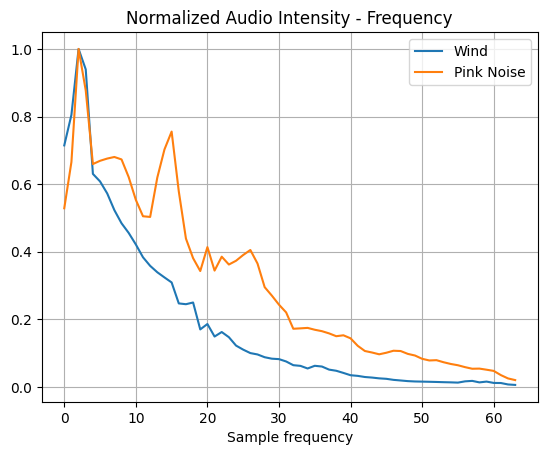

In [36]:
import matplotlib.pyplot as plt 
plt.plot(avg_wind.mean(axis=0)/avg_wind.mean(axis=0).max(),label='Wind')
plt.plot(avg_pink.mean(axis=0)/avg_pink.mean(axis=0).max(),label='Pink Noise')
# plt.plot(avg_bell.mean(axis=0),label='Bell')
plt.grid()
plt.legend()
plt.title("Normalized Audio Intensity - Frequency")
plt.xlabel("Sample frequency")

In [94]:
import colorednoise as cn
cn.powerlaw_psd_gaussian(1, 44100)

array([-0.56883903, -0.19199747, -0.0815009 , ..., -0.48156126,
       -0.39845553,  0.24269987])

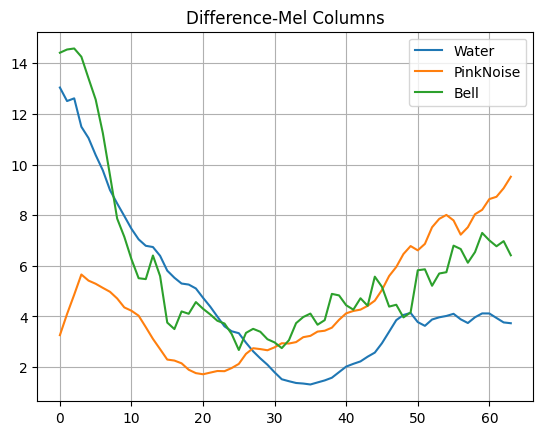

In [46]:
import matplotlib.pyplot as plt

# plt.plot(torch.abs(mel_1.mean(dim=0)-mel_1[1]).mean(dim=1),label='Sample from Wind')
plt.plot(torch.abs(mel_1.mean(dim=0)-mel_2.mean(dim=0)).mean(dim=1),label='Water')
plt.plot(torch.abs(mel_1.mean(dim=0)-mel_3.mean(dim=0)).mean(dim=1),label='PinkNoise')
plt.plot(torch.abs(mel_1.mean(dim=0)-mel_4.mean(dim=0)).mean(dim=1),label='Bell')
plt.title("Difference-Mel Columns")
plt.grid()
plt.legend()

In [1]:
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/pink_wind/training/'
os.listdir(root)
pink_wind_res = {
    'pink':{},
    'wind':{}
}
for snr in [0,5,10,15]:
    for train_type in [4,9]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            sub_dir = f'TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_4_None_AudioSet{train_type}({snr})_AudioSet{snr}_0/_test{test_type}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = 'pink' if train_type==9 else 'wind'
                if snr in pink_wind_res[train_noise]:
                    pink_wind_res[train_noise][snr].append(data['f1']['all'])
                else:
                    pink_wind_res[train_noise][snr] = [data['f1']['all']]
            

In [2]:
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/pure_pink/training/'
os.listdir(root)
pure_pink = {
    'pink':{},
}
for snr in [0,5,10,15]:
    for train_type in [5]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            sub_dir = f'TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_4_None_AudioSet{train_type}({snr})_AudioSet{snr}_0/_test{test_type}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = 'pink'
                if snr in pure_pink[train_noise]:
                    pure_pink[train_noise][snr].append(data['f1']['all'])
                else:
                    pure_pink[train_noise][snr] = [data['f1']['all']]
            

In [1]:
mapping = {
    0: 'Wild animals',
 1: 'Domestic animals, pets',
 2: 'Bell',
 3: 'Alarm',
 4: 'Wind',
 5: 'Water',
#  6: 'Wild animals+Domestic animals, pets',
#  7: 'Bell+Alarm',
#  8: 'Wind+Water'
 }

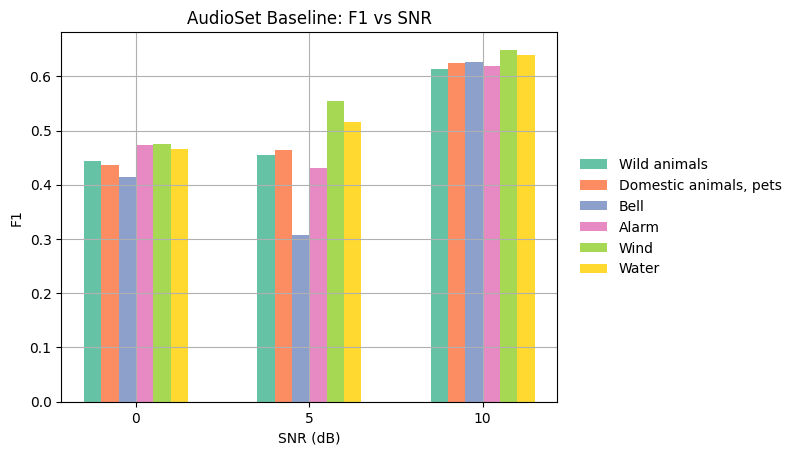

In [17]:
import numpy as np
import matplotlib.pyplot as plt

data = pure_pink['pink']

# 只用 0, 5, 10 作为横坐标
x = np.array([0, 5, 10])

# 取前 8 列
values = np.array([data[k][:8] for k in x])   # shape: [3, 8]

n_groups = len(mapping)   # 8
bar_width = 0.1
colors = plt.cm.Set2.colors
# plt.figure(figsize=(8, 4))

for i in range(n_groups):
    plt.bar(
        np.arange(len(x)) + (i - (n_groups - 1) / 2) * bar_width,
        values[:, i],
        width=bar_width,
        color=colors[i % len(colors)],
        label=f'{mapping[i]}'
    )

plt.xlabel('SNR (dB)')
plt.ylabel('F1')
plt.title('AudioSet Baseline: F1 vs SNR')
plt.xticks(np.arange(len(x)), x)
# plt.legend(loc="center left",frameon=False)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.grid()
plt.show()

In [21]:
def plot_bar_noise(data,title):


# data = pure_pink['pink']

    # 只用 0, 5, 10 作为横坐标
    x = np.array([0, 5, 10])

    # 取前 8 列
    values = np.array([data[k][:8] for k in x])   # shape: [3, 8]

    n_groups = len(mapping)   # 8
    bar_width = 0.1
    colors = plt.cm.Set2.colors
    # plt.figure(figsize=(8, 4))

    for i in range(n_groups):
        plt.bar(
            np.arange(len(x)) + (i - (n_groups - 1) / 2) * bar_width,
            values[:, i],
            width=bar_width,
            color=colors[i % len(colors)],
            label=f'{mapping[i]}'
        )

    plt.xlabel('SNR (dB)')
    plt.ylabel('F1')
    plt.title(title)
    plt.xticks(np.arange(len(x)), x)
    # plt.legend(loc="center left",frameon=False)
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # plt.tight_layout()
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.grid()
    plt.show()

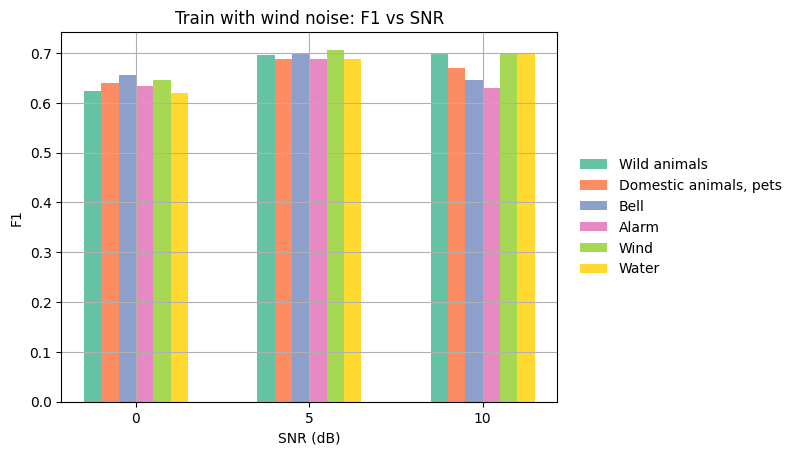

In [31]:
import numpy as np
import matplotlib.pyplot as plt

data = pink_wind_res['wind']

# 只用 0, 5, 10 作为横坐标
x = np.array([0, 5, 10])
x_pos = np.arange(3)
# 取前 8 列
values = np.array([data[k][:8] for k in x])   # shape: [3, 8]

n_groups = 6   # 8
bar_width = 0.1
colors = plt.cm.Set2.colors
# plt.figure(figsize=(8, 4))

for i in range(n_groups):
    plt.bar(
        x_pos + (i - (n_groups - 1) / 2) * bar_width,
        values[:, i],
        width=bar_width,
        color=colors[i % len(colors)],
        label=f'{mapping[i]}'
    )

plt.xlabel('SNR (dB)')
plt.ylabel('F1')
plt.title('Train with wind noise: F1 vs SNR')
plt.xticks(x_pos, x)
# plt.legend(loc="center left",frameon=False)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.grid()
plt.show()

In [32]:
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/bell/training/'
os.listdir(root)
bell_res = {
    'bell':{},
}
for snr in [0,5,10,15]:
    for train_type in [5]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            sub_dir = f'TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_4_None_AudioSet{train_type}({snr})_AudioSet{snr}_0/_test{test_type}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = 'bell'
                if snr in bell_res[train_noise]:
                    bell_res[train_noise][snr].append(data['f1']['all'])
                else:
                    bell_res[train_noise][snr] = [data['f1']['all']]
            

In [42]:
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/bell/training/'
os.listdir(root)
bell_res = {
    'bell':{},
}
for snr in [0,5,10]:
    for train_type in [2]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            sub_dir = f'SpeechCommands-16k_Cnn10-32k-T_Adam_0.001_512_epoch_1_None_AudioSet{train_type}({snr})_AudioSet{snr}_0/_test{test_type}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = 'bell'
                if snr in bell_res[train_noise]:
                    bell_res[train_noise][snr].append(data['f1']['all'])
                else:
                    bell_res[train_noise][snr] = [data['f1']['all']]

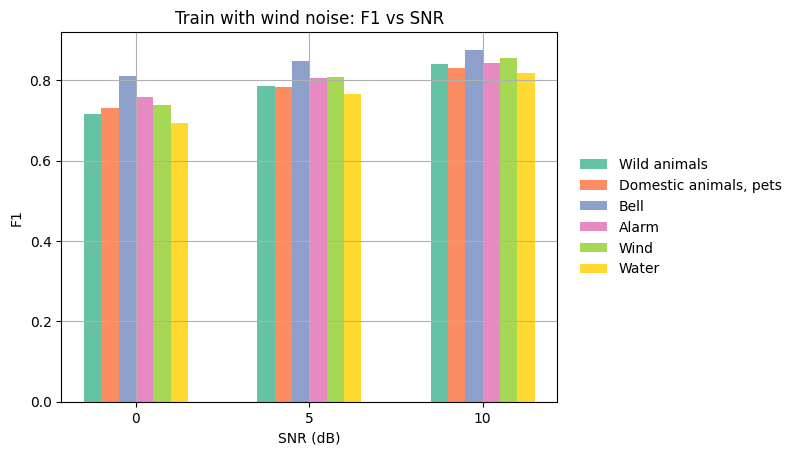

In [46]:
plot_bar_noise(bell_res['bell'], 'Train with wind noise: F1 vs SNR')

In [4]:
mapping = {
    0: 'Wild animals',
 1: 'Domestic animals, pets',
 2: 'Bell',
 3: 'Alarm',
 4: 'Wind',
 5: 'Water',
#  6: 'Wild animals+Domestic animals, pets',
#  7: 'Bell+Alarm',
#  8: 'Wind+Water'
 }

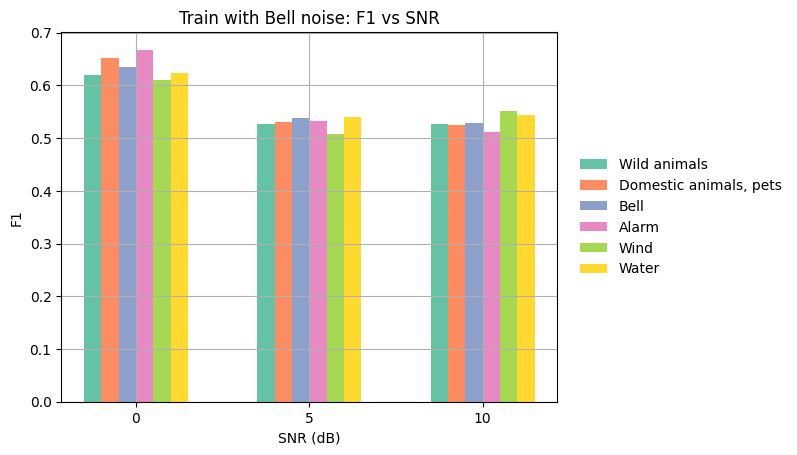

In [34]:
import numpy as np
import matplotlib.pyplot as plt

data = bell_res['bell']

# 只用 0, 5, 10 作为横坐标
x = np.array([0, 5, 10])

# 取前 8 列
values = np.array([data[k][:8] for k in x])   # shape: [3, 8]

n_groups = 6   # 8
bar_width = 0.1
colors = plt.cm.Set2.colors
# plt.figure(figsize=(8, 4))
x_pos = np.arange(3)

for i in range(n_groups):
    plt.bar(
        x_pos + (i - (n_groups - 1) / 2) * bar_width,
        values[:, i],
        width=bar_width,
        color=colors[i % len(colors)],
        label=f'{mapping[i]}'
    )

plt.xlabel('SNR (dB)')
plt.ylabel('F1')
plt.title('Train with Bell noise: F1 vs SNR')
plt.xticks(x_pos, x)
# plt.legend(loc="center left",frameon=False)
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# plt.tight_layout()
# plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.grid()
plt.show()

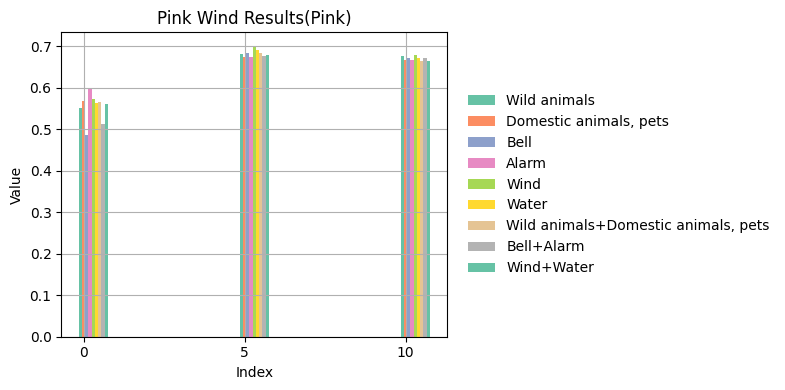

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# x 轴主刻度
x_labels = [0, 5, 10]

# 取数据，每个都是长度为 8 的 list
data = [
    pink_wind_res['pink'][0],
    pink_wind_res['pink'][5],
    pink_wind_res['pink'][10],
    # pink_wind_res['pink'][15],
]

data = np.array(data)   # shape = [4, 8]

num_groups = data.shape[0]   # 4
num_bars = data.shape[1]     # 8

# 每组柱子的宽度控制
bar_width = 0.1
colors = plt.cm.Set2.colors

# 每个 group 的中心位置
# x = np.arange(num_groups)
x = np.array([0,5,10])

plt.figure(figsize=(8, 4))

for i in range(num_bars):
    plt.bar(
        x + (i - (num_groups - 1) / 2) * bar_width,
        data[:, i],
        width=bar_width,
        color=colors[i % len(colors)],
        label=mapping[i]
    )

plt.xticks(x, x_labels)
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Train with Wind noise: F1 vs SNR")
plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.grid()
plt.tight_layout()
plt.show()


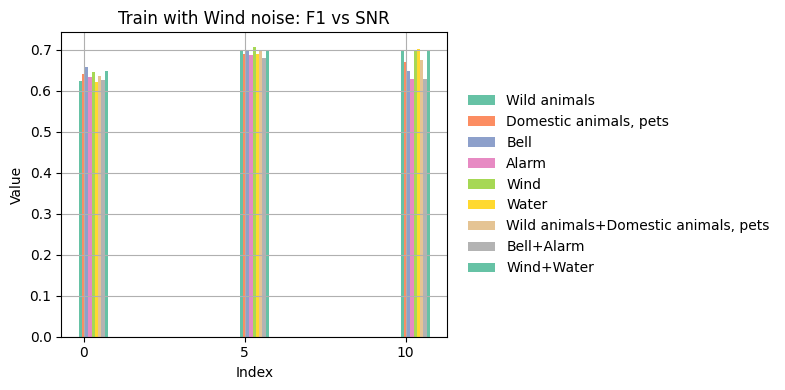

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# x 轴主刻度
x_labels = [0, 5, 10]

# 取数据，每个都是长度为 8 的 list
data = [
    pink_wind_res['wind'][0],
    pink_wind_res['wind'][5],
    pink_wind_res['wind'][10],
    # pink_wind_res['wind'][15],
]

data = np.array(data)   # shape = [4, 8]

num_groups = data.shape[0]   # 4
num_bars = data.shape[1]     # 8

# 每组柱子的宽度控制
bar_width = 0.1
colors = plt.cm.Set2.colors

# 每个 group 的中心位置
# x = np.arange(num_groups)
x = np.array([0,5,10])

plt.figure(figsize=(8, 4))

for i in range(num_bars):
    plt.bar(
        x + (i - (num_groups - 1) / 2) * bar_width,
        data[:, i],
        width=bar_width,
        color=colors[i % len(colors)],
        label=mapping[i]
    )

plt.xticks(x, x_labels)
plt.xlabel("Index")
plt.ylabel("Value")
# plt.title("Pink Wind Results(Wind)")
plt.title("Train with Wind noise: F1 vs SNR")

plt.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
plt.grid()
plt.tight_layout()
plt.show()


In [12]:
pink_wind_res['wind'][15]

[0.7061671895545557,
 0.702327916813955,
 0.701534196923892,
 0.7044354089487976,
 0.7110144275285012,
 0.7030006619682764,
 0.7133734523408659,
 0.6945733231623717,
 0.7044868759640309]

In [1]:
# wind_sub
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/wind_sub/training/'
os.listdir(root)
wind_sub = {
    '0':{},
    '1':{},
    '2':{},
    '3':{},
}
for snr in [0,5,10,15]:
    for col_range in [0,1,2,3]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            sub_dir = f'TIMIT-sentencetype-16k_Cnn10-32k-T_Adam_0.001_64_epoch_4_None_AudioSet4-{col_range}-({snr})_AudioSet{snr}_0/_test{test_type}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = f'{col_range}'
                if snr in wind_sub[train_noise]:
                    wind_sub[train_noise][snr].append(data['f1']['all'])
                else:
                    wind_sub[train_noise][snr] = [data['f1']['all']]
            

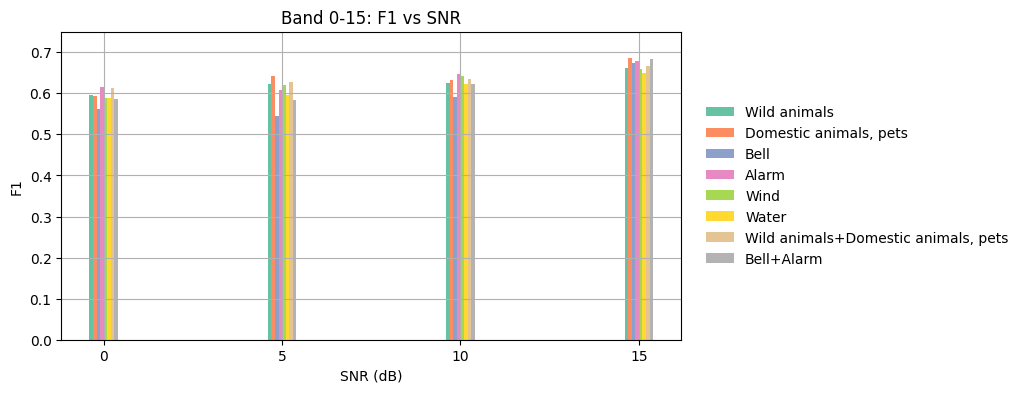

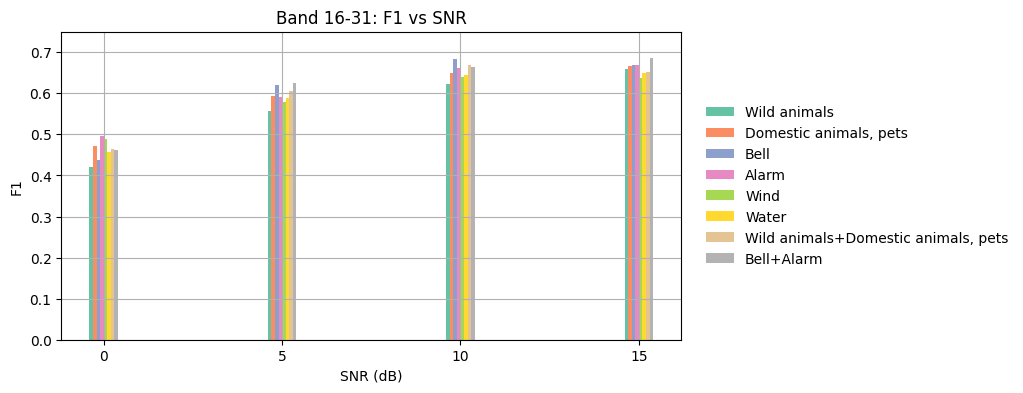

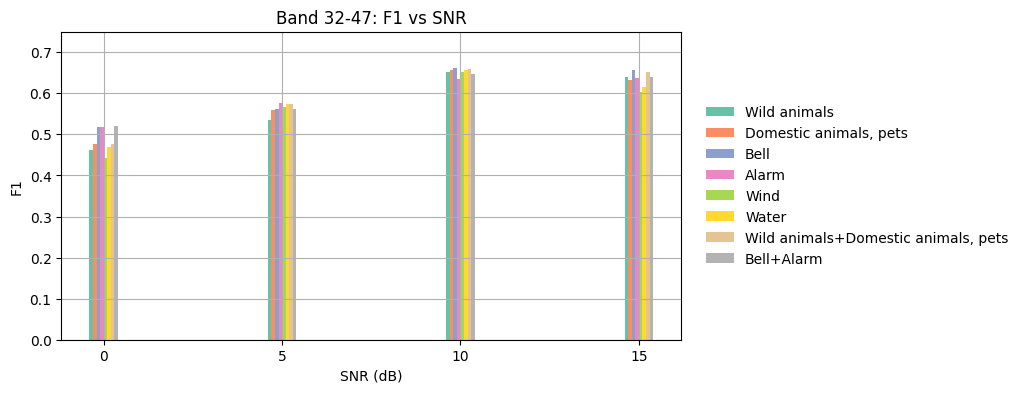

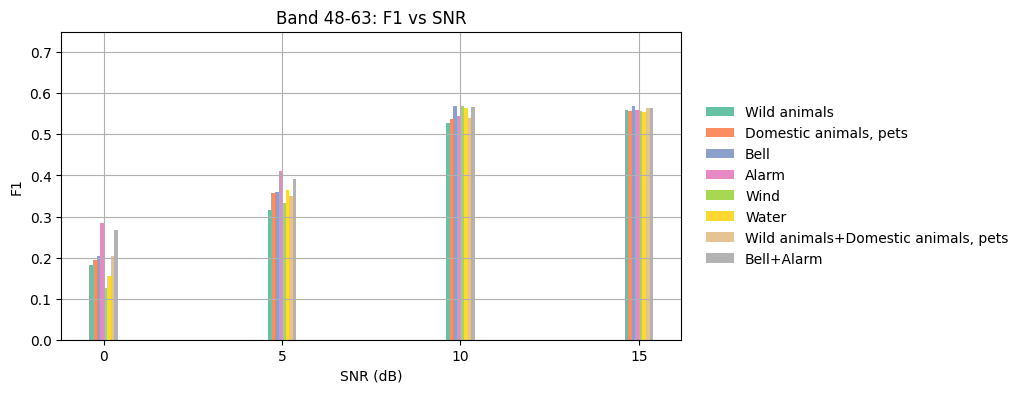

In [20]:
import numpy as np
import matplotlib.pyplot as plt

for col in [0,1,2,3]:
    data = wind_sub[f'{col}']

    # 只用 0, 5, 10 作为横坐标
    x = np.array([0, 5, 10, 15])

    # 取前 8 列
    values = np.array([data[k][:8] for k in x])   # shape: [3, 8]

    n_groups = values.shape[1]   # 8
    bar_width = 0.1
    colors = plt.cm.Set2.colors
    plt.figure(figsize=(8, 4))

    for i in range(n_groups):
        plt.bar(
            x + (i - (n_groups - 1) / 2) * bar_width,
            values[:, i],
            width=bar_width,
            color=colors[i % len(colors)],
            label=f'{mapping[i]}'
        )

    plt.xlabel('SNR (dB)')
    plt.ylabel('F1')
    plt.title(f'Band {col*16}-{(col+1)*16-1}: F1 vs SNR')
    plt.xticks(x)
    # plt.legend(loc="center left",frameon=False)
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # plt.tight_layout()
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.ylim(0, 0.75)
    plt.grid()
    plt.show()

In [47]:
# speechcommand
# wind_sub
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/bell/training/'
os.listdir(root)
wind_sub = {
    '0':{},
    '1':{},
    '2':{},
    '3':{},
}
for snr in [0,5,10]:
    # for col_range in [0,1,2,3]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            # SpeechCommands-16k_Cnn10-32k-T_Adam_0.001_512_epoch_1_None_AudioSet2(0)_AudioSet0_0
            sub_dir = f'SpeechCommands-16k_Cnn10-32k-T_Adam_0.001_512_epoch_1_None_AudioSet4({snr})_AudioSet{snr}_0/_test{test_type}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = f'{col_range}'
                if snr in wind_sub[train_noise]:
                    wind_sub[train_noise][snr].append(data['f1']['all'])
                else:
                    wind_sub[train_noise][snr] = [data['f1']['all']]
            

In [49]:
import numpy as np
import matplotlib.pyplot as plt

for col in [0,1,2,3]:
    data = wind_sub[f'{col}']

    # 只用 0, 5, 10 作为横坐标
    x = np.array([0, 5, 10])
    x_pos = np.arange(3)
    # 取前 8 列
    values = np.array([data[k][:6] for k in x])   # shape: [3, 8]

    n_groups = values.shape[1]   # 8
    bar_width = 0.1
    colors = plt.cm.Set2.colors
    # plt.figure(figsize=(8, 4))

    for i in range(n_groups):
        plt.bar(
            x_pos + (i - (n_groups - 1) / 2) * bar_width,
            values[:, i],
            width=bar_width,
            color=colors[i % len(colors)],
            label=f'{mapping[i]}'
        )

    plt.xlabel('SNR (dB)')
    plt.ylabel('F1')
    plt.title(f'SpeechCommand(Train with wind noise): F1 vs SNR')
    plt.xticks(x_pos, x)
    # plt.legend(loc="center left",frameon=False)
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # plt.tight_layout()
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.ylim(0, 1)
    plt.grid()
    plt.show()

KeyError: np.int64(0)

In [35]:
# speechcommand
# wind_sub
# TODO: 收集结果
# 结果文件夹结构：每个子文件夹的snr是固定的，训练噪声也是确定的，8个_test对应8种测试噪声
import os 
import yaml
root = './results/speech_baseline/training/'
os.listdir(root)
wind_sub = {
    '0':{},
    '1':{},
    '2':{},
    '3':{},
}
for i,snr in enumerate([0,5, 10]):
    for col_range in [0,1,2,3]:
        for test_type in [0,1,2,3,4,5,6,7,8]:
            # SpeechCommands-16k_Cnn10-32k-T_Adam_0.001_512_epoch_1_None_AudioSet2(0)_AudioSet0_0
            # SpeechCommands-16k_Cnn10-32k-T_Adam_0.001_512_epoch_1_None_None_AudioSetBaseline0-15_0
        
            sub_dir = f'SpeechCommands-16k_Cnn10-32k-T_Adam_0.001_512_epoch_1_None_None_AudioSetBaseline0-15_0/_test{test_type+i*9}/test_holistic.yaml'
            with open(os.path.join(root, sub_dir), "r") as f:
                data = yaml.safe_load(f)   # ← 正确方式
                # print(data['f1']['all'])
                # print(snr, data['f1']['all'])
                train_noise = f'{col_range}'
                if snr in wind_sub[train_noise]:
                    wind_sub[train_noise][snr].append(data['f1']['all'])
                else:
                    wind_sub[train_noise][snr] = [data['f1']['all']]
            

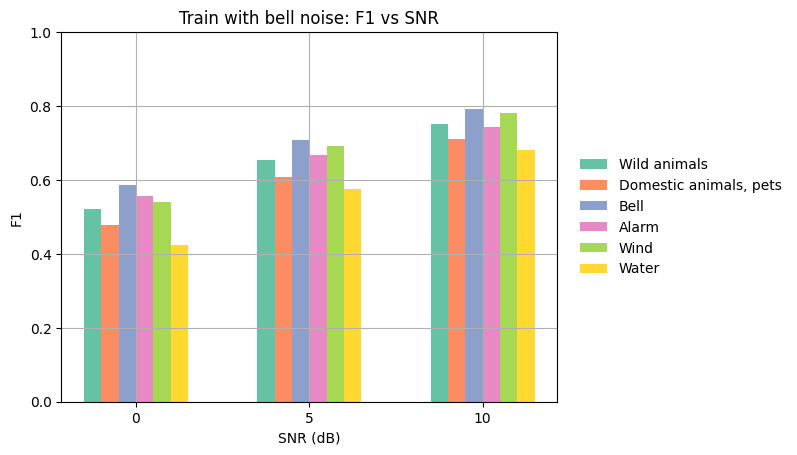

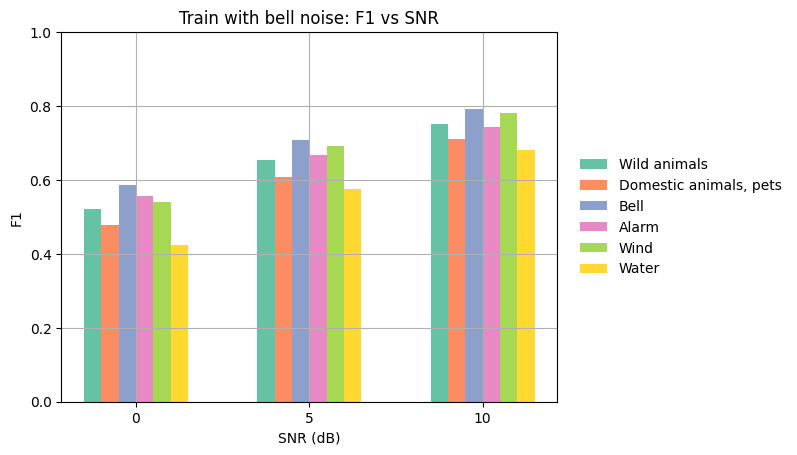

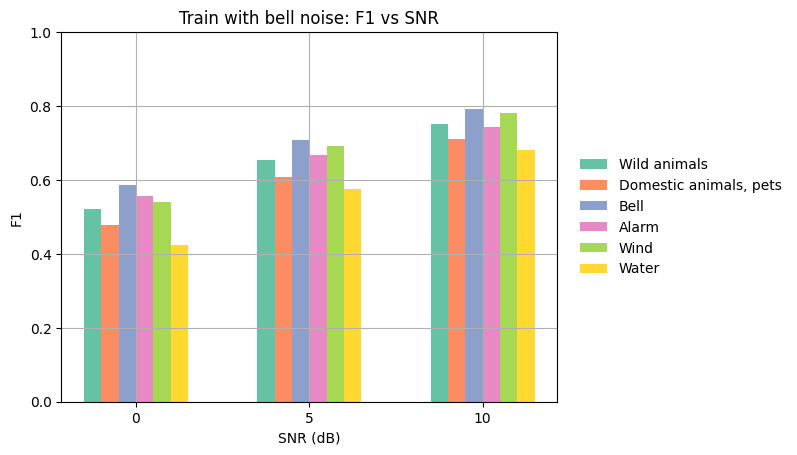

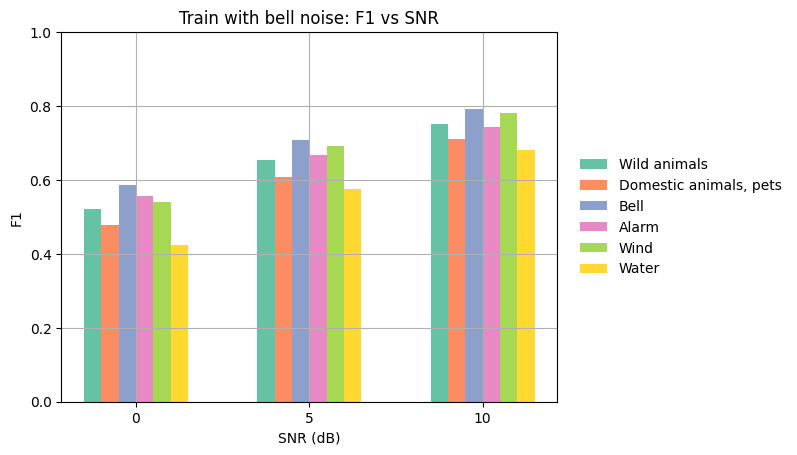

In [45]:
import numpy as np
import matplotlib.pyplot as plt

for col in [0,1,2,3]:
    data = wind_sub[f'{col}']

    # 只用 0, 5, 10 作为横坐标
    x = np.array([0, 5, 10])
    x_pos = np.arange(3)
    # 取前 8 列
    values = np.array([data[k][:8] for k in x])   # shape: [3, 8]

    n_groups = 6   # 8
    bar_width = 0.1
    colors = plt.cm.Set2.colors
    # plt.figure(figsize=(8, 4))

    for i in range(n_groups):
        plt.bar(
            x_pos + (i - (n_groups - 1) / 2) * bar_width,
            values[:, i],
            width=bar_width,
            color=colors[i % len(colors)],
            label=f'{mapping[i]}'
        )

    plt.xlabel('SNR (dB)')
    plt.ylabel('F1')
    plt.title(f'Train with bell noise: F1 vs SNR')
    plt.xticks(x_pos, x)
    # plt.legend(loc="center left",frameon=False)
    plt.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=False
    )

    # plt.tight_layout()
    # plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.ylim(0, 1)
    plt.grid()
    plt.show()